# Short comparison between your public test result and hidden test result.
By using the Pretrained Transformer Encoder-only Distilroberta model, I achieved accuracy of 74.83% (with no retraining) when tested with the (unseen data) hidden test data provided as part of stage-2. This accuracy is very close to the accuracy when I tested with the public test data provided in stage-1 i.e. 77.75%. Hence this shows the model has learnt to identify the pattern correctly without overfitting or underfitting and achieved better generilization.

# if you had more time or compute, what would you try next?
If I had more time, I would have tried with different approaches with the combinations of different batch sizes and k-fold along with respective learning rate. Also, I would have tried the same with larger model with higher number of weights and with LLM based models to achieve over 90% accuracy

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 105/105 [00:00<00:00, 6772.91it/s]


Loaded checkpoint from 'model_checkpoint/'
Hidden Test Shape: (600, 5)

Hidden Test Label Distribution:
label
0    300
1    300
Name: count, dtype: int64

--- Hidden Test Accuracy: 74.83% ---
--- Hidden Test Macro F1: 0.7479 ---

Classification Report:
              precision    recall  f1-score   support

Negative (0)     0.7709    0.7067    0.7374       300
Positive (1)     0.7292    0.7900    0.7584       300

    accuracy                         0.7483       600
   macro avg     0.7501    0.7483    0.7479       600
weighted avg     0.7501    0.7483    0.7479       600



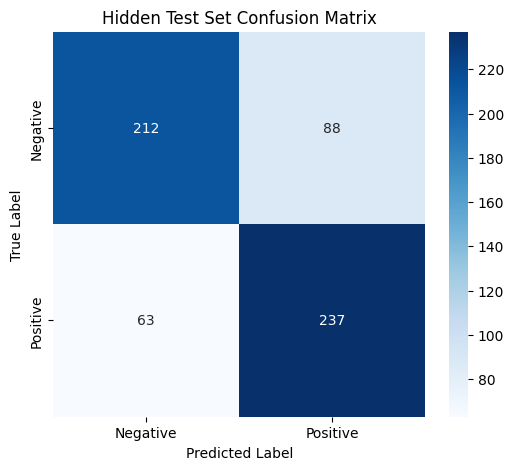

Saved predictions to 'hidden_test_predictions.csv'

Misclassified: 151 / 600
                 id  true_label  predicted_label  prob_positive
11  pos_cv932_13401           1                0         0.0085
14   pos_cv090_0042           1                0         0.0139
15   pos_cv664_4389           1                0         0.0084
19  neg_cv656_25395           0                1         0.9895
21   neg_cv124_3903           0                1         0.9949
22   neg_cv333_9443           0                1         0.9824
24  neg_cv069_11613           0                1         0.7107
29  pos_cv401_12605           1                0         0.3197
37  pos_cv784_14394           1                0         0.0522
48  neg_cv276_17126           0                1         0.9582


In [1]:
# %% [Stage 2] Evaluate the saved checkpoint on the hidden test set
# Self-contained: reloads model + tokenizer from disk, so this runs even on a
# fresh kernel without re-running the training cells.

import os
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SAVE_DIR = "model_checkpoint"
HIDDEN_CSV = "hidden_test_with_labels.csv"
MAX_LEN = 256          # must match training
EVAL_BATCH_SIZE = 8

device = torch.device("cuda" if torch.cuda.is_available()
                      else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

# --- Load the saved weights (no retraining) ---
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
model.eval()
print(f"Loaded checkpoint from '{SAVE_DIR}/'")

# --- Load hidden test data ---
hidden_df = pd.read_csv(HIDDEN_CSV)
print(f"Hidden Test Shape: {hidden_df.shape}")
print("\nHidden Test Label Distribution:")
print(hidden_df['label'].value_counts())


class HiddenTestDataset(Dataset):
    def __init__(self, texts, labels=None, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


hidden_dataset = HiddenTestDataset(hidden_df['text'].values, hidden_df['label'].values)
hidden_loader = DataLoader(hidden_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)

# --- Inference ---
hidden_preds, hidden_labels, hidden_probs = [], [], []

with torch.no_grad():
    for batch in hidden_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['labels'].to(device)

        logits = model(input_ids, attention_mask=attention_mask).logits
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)

        hidden_preds.extend(preds.cpu().numpy())
        hidden_labels.extend(targets.cpu().numpy())
        hidden_probs.extend(probs[:, 1].cpu().numpy())

hidden_preds = np.array(hidden_preds)
hidden_labels = np.array(hidden_labels)

# --- Metrics ---
accuracy = accuracy_score(hidden_labels, hidden_preds)
macro_f1 = f1_score(hidden_labels, hidden_preds, average='macro')

print(f"\n--- Hidden Test Accuracy: {accuracy * 100:.2f}% ---")
print(f"--- Hidden Test Macro F1: {macro_f1:.4f} ---\n")
print("Classification Report:")
print(classification_report(hidden_labels, hidden_preds,
                            target_names=["Negative (0)", "Positive (1)"],
                            digits=4))

cm = confusion_matrix(hidden_labels, hidden_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Hidden Test Set Confusion Matrix")
plt.show()

# --- Save predictions ---
hidden_output_df = pd.DataFrame({
    'id': hidden_df['id'],
    'true_label': hidden_labels,
    'predicted_label': hidden_preds,
    'prob_positive': np.round(hidden_probs, 4)
})
hidden_output_df.to_csv("hidden_test_predictions.csv", index=False)
print("Saved predictions to 'hidden_test_predictions.csv'")

# --- Quick error inspection ---
errors = hidden_output_df[hidden_output_df['true_label'] != hidden_output_df['predicted_label']]
print(f"\nMisclassified: {len(errors)} / {len(hidden_output_df)}")
print(errors.head(10))
